[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/SFM/blob/main/Quantlets/Ch_05/SFM_ch5_seminar/SFM_ch5_seminar.ipynb)

# Statistics of Financial Markets — Seminar 5: Heavy tails and extreme value theory

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The slides "Prerequisites for Today" give every definition used here.
- Part A: computations on paper, checked in code. Part B: real data with a measure of precision and an interpretation question. Part C: an open question and an AI answer to audit.
- **[Solved]**: complete code and output, a model to follow. **[Proposed]**: write your own code in the empty cell.

> Quantlet `SFM_ch5_seminar`: student version of the Seminar 5 notebook. Solved exercises (A1, A3, A5, A7, B1, B3, B5) are shown with code and output; the proposed exercises (A2, A4, A6, A8, B2, B4, B6, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/SFM/Chapter_5'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import sfm_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the SFM repository (read locally, or from GitHub in Colab); EUR/RON is the official BNR reference rate.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/SFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the SFM repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years

## Seminar functions

- Losses $L_t = -r_t$ (%), the Hill estimator with inference, GEV and GPD fits by maximum likelihood, POT VaR and ES, historical and Normal VaR and ES, the mean excess function.
- Helpers for Part A: Hill from a list of losses, Pareto tails, GEV probabilities and return levels, POT formulas.

In [ ]:
from scipy import optimize
START = {'sp500': '1990-01-01', 'dax': '1990-01-01', 'bet': '1997-01-01', 'btc': None, 'snp': '2010-01-01', 'brd': '2010-01-01', 'tlv': '2010-01-01', 'tgn': '2010-01-01'}
ASSETS = ['sp500', 'dax', 'bet', 'btc']
STOCKS = ['snp', 'brd', 'tlv', 'tgn']
BAD_DAYS = {'tlv': ['2016-05-30', '2016-05-31']}
COLORS = {'sp500': '#1A3A6E', 'dax': '#17A2B8', 'bet': '#CD0000', 'btc': '#B5853F', 'snp': '#2E7D32', 'brd': '#8E44AD', 'tlv': '#E67E22', 'tgn': '#DC3545'}
MODEL_COL = {'Data': '#B5853F', 'Normal': '#CD0000', 'EVT': '#1A3A6E', 'Historical': '#2E7D32', 'Hill': '#8E44AD'}
SEED = 2026
HILL_FRAC = 0.025
POT_Q = 0.9
SPLIT = '2019-12-31'
BLOCK = 20


def returns(k):
    """Daily log returns in % on the series' own calendar (S&P 500 and DAX since 1990, BET since its launch in
    1997, Bitcoin since 2014, BVB stocks since 2010); known data errors removed."""
    r = log_returns(k, START.get(k))
    if k in BAD_DAYS:
        r = r.drop(pd.to_datetime(BAD_DAYS[k]), errors='ignore')
    return r


def losses(k):
    """Daily losses L_t = -r_t in % (a positive number is a loss)."""
    return -returns(k)


def hill(x, k):
    """Hill (1975): alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^(-1), X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x, float))[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def hill_quantile(x, k, p):
    """Hill (Weissman, 1978) quantile: x_p = X_(k+1) (k / (n p))^(1/alpha_hat), the loss exceeded with probability p."""
    x = np.sort(np.asarray(x, float))[::-1]
    return x[k] * (k / (len(x) * p)) ** (1 / hill(x, k))


def ls_tail_index(x, k):
    """Least-squares tail index (as in SFElshill): slope of ln(i/n) on ln X_(i), i = 1..k, is -alpha."""
    n = len(x)
    x = np.sort(np.asarray(x, float))[::-1][:k]
    return -np.polyfit(np.log(x), np.log(np.arange(1, k + 1) / n), 1)[0]


def block_indices(n, block, rng):
    """Indices of one moving-block bootstrap sample (blocks of `block` consecutive days)."""
    nb = int(np.ceil(n / block))
    s = rng.integers(0, n - block + 1, nb)
    return (s[:, None] + np.arange(block)[None, :]).ravel()[:n]


def hill_inference(x, frac=HILL_FRAC, B=500, block=BLOCK, seed=SEED):
    """Hill alpha_hat at k = frac n with the i.i.d. standard error alpha/sqrt(k), the 95% interval
    alpha (1 +/- 1.96/sqrt(k)) and the moving-block bootstrap standard error (blocks of 20 days)."""
    x = np.asarray(x, float)
    n = len(x)
    k = int(frac * n)
    a = hill(x, k)
    rng = np.random.default_rng(seed)
    bs = np.array([hill(x[block_indices(n, block, rng)], k) for _ in range(B)])
    return {'n': n, 'k': k, 'u': float(np.sort(x)[::-1][k]), 'alpha': a, 'se_iid': a / np.sqrt(k),
            'lo': a * (1 - 1.96 / np.sqrt(k)), 'hi': a * (1 + 1.96 / np.sqrt(k)), 'se_block': float(np.std(bs, ddof=1)),
            'alpha_1': hill(x, int(0.01 * n)), 'alpha_5': hill(x, int(0.05 * n)), 'ls': ls_tail_index(x, k)}


def gev_cdf(x, xi, mu, sigma):
    """GEV distribution function H(x) = exp{-[1 + xi (x - mu)/sigma]^(-1/xi)} (xi = 0: Gumbel)."""
    return stats.genextreme.cdf(x, -xi, mu, sigma)          # scipy's shape c = -xi


def gev_ppf(p, xi, mu, sigma):
    return stats.genextreme.ppf(p, -xi, mu, sigma)


def gev_pdf(x, xi, mu, sigma):
    return stats.genextreme.pdf(x, -xi, mu, sigma)


def gpd_sf(y, xi, beta):
    """GPD survival function P(Y > y) = (1 + xi y / beta)^(-1/xi) for the excess Y = X - u (xi = 0: exponential)."""
    return stats.genpareto.sf(y, xi, 0, beta)


def num_hessian(f, p, h=1e-4):
    """Numerical Hessian of f at p (central differences)."""
    p = np.asarray(p, float)
    k = len(p)
    H = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            e_i, e_j = np.eye(k)[i] * h, np.eye(k)[j] * h
            H[i, j] = (f(p + e_i + e_j) - f(p + e_i - e_j) - f(p - e_i + e_j) + f(p - e_i - e_j)) / (4 * h * h)
    return H


def fit_gev(m):
    """Maximum likelihood GEV fit (xi, mu, sigma) of block maxima m, standard errors from the numerical Hessian."""
    m = np.asarray(m, float)
    c, mu, sig = stats.genextreme.fit(m, -0.1, loc=np.mean(m), scale=np.std(m))
    nll = lambda p: -np.sum(stats.genextreme.logpdf(m, -p[0], p[1], p[2])) if p[2] > 0 else np.inf
    res = optimize.minimize(nll, [-c, mu, sig], method='Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 5000})
    xi, mu, sig = res.x
    cov = np.linalg.inv(num_hessian(nll, res.x))
    se = np.sqrt(np.diag(cov))
    return {'xi': xi, 'mu': mu, 'sigma': sig, 'se_xi': se[0], 'se_mu': se[1], 'se_sigma': se[2], 'nll': res.fun, 'n': len(m)}


def fit_gpd(y):
    """Maximum likelihood GPD fit (xi, beta) of excesses y > 0, standard errors from the numerical Hessian."""
    y = np.asarray(y, float)
    c, _, b = stats.genpareto.fit(y, floc=0)
    nll = lambda p: -np.sum(stats.genpareto.logpdf(y, p[0], 0, p[1])) if p[1] > 0 else np.inf
    res = optimize.minimize(nll, [c, b], method='Nelder-Mead', options={'xatol': 1e-9, 'fatol': 1e-9, 'maxiter': 5000})
    xi, beta = res.x
    se = np.sqrt(np.diag(np.linalg.inv(num_hessian(nll, res.x))))
    return {'xi': xi, 'beta': beta, 'se_xi': se[0], 'se_beta': se[1], 'nll': res.fun, 'n_u': len(y)}


def return_level(g, months):
    """Level exceeded by the monthly maximum on average once every `months` months: z = H^(-1)(1 - 1/months)."""
    return float(gev_ppf(1 - 1 / months, g['xi'], g['mu'], g['sigma']))


def pot(x, q=POT_Q):
    """GPD fit to the losses above the threshold u = q-quantile of the losses x."""
    x = np.asarray(x, float)
    u = float(np.quantile(x, q))
    f = fit_gpd(x[x > u] - u)
    f.update({'u': u, 'n': len(x), 'q': q})
    return f


def pot_var(f, p):
    """VaR_p = u + (beta/xi) [ (n p / N_u)^(-xi) - 1 ], the loss exceeded with probability p."""
    return f['u'] + f['beta'] / f['xi'] * ((f['n'] * p / f['n_u']) ** (-f['xi']) - 1)


def pot_es(f, p):
    """ES_p = VaR_p / (1 - xi) + (beta - xi u) / (1 - xi), the mean loss beyond VaR_p (xi < 1)."""
    return pot_var(f, p) / (1 - f['xi']) + (f['beta'] - f['xi'] * f['u']) / (1 - f['xi'])


def pot_tail_prob(f, x):
    """P(L > x) = (N_u / n) (1 + xi (x - u) / beta)^(-1/xi) for x > u."""
    return f['n_u'] / f['n'] * (1 + f['xi'] * (np.asarray(x, float) - f['u']) / f['beta']) ** (-1 / f['xi'])


def normal_var(x, p):
    """Normal VaR_p of losses x: mu_L + sigma_L z_(1-p)."""
    return float(np.mean(x) + np.std(x, ddof=1) * stats.norm.isf(p))


def normal_es(x, p):
    """Normal ES_p of losses x: mu_L + sigma_L phi(z_p) / p."""
    return float(np.mean(x) + np.std(x, ddof=1) * stats.norm.pdf(stats.norm.isf(p)) / p)


def hist_var(x, p):
    """Historical VaR_p: the empirical (1 - p) quantile of the losses."""
    return float(np.quantile(x, 1 - p))


def hist_es(x, p):
    """Historical ES_p: the mean of the losses at or above the historical VaR_p."""
    x = np.asarray(x, float)
    return float(x[x >= hist_var(x, p)].mean())


def mean_excess(x, us):
    """Empirical mean excess e(u) = mean of (X - u) over the observations X > u."""
    x = np.asarray(x, float)
    return np.array([np.mean(x[x > u] - u) if np.sum(x > u) >= 5 else np.nan for u in us])


def hill_from_list(top, n, p=0.001):
    """Hill on the k+1 largest losses given in decreasing order: alpha_hat, SE, 95% CI and the Hill (Weissman)
    quantile x_p = L_(k+1) (k / (n p))^(1/alpha_hat)."""
    top = np.asarray(top, float)
    k = len(top) - 1
    logs = np.log(top[:k] / top[k])
    a = 1 / logs.mean()
    return {'k': k, 'logs': logs.tolist(), 'mean_log': logs.mean(), 'alpha': a, 'se': a / np.sqrt(k),
            'lo': a * (1 - 1.96 / np.sqrt(k)), 'hi': a * (1 + 1.96 / np.sqrt(k)), 'ratio': k / (n * p),
            'factor': (k / (n * p)) ** (1 / a), 'xp': top[k] * (k / (n * p)) ** (1 / a)}


def pareto_tail(x0, p0, alpha, xs=(5, 10), ps=(0.01, 0.001), u=None):
    """Pareto tail P(L > x) = p0 (x / x0)^(-alpha), x >= x0: tail probabilities, VaR_p = x0 (p0/p)^(1/alpha),
    ES_p = VaR_p alpha / (alpha - 1) and the mean excess e(u) = u / (alpha - 1)."""
    out = {'p': {x: p0 * (x / x0) ** -alpha for x in xs}}
    out['var'] = {p: x0 * (p0 / p) ** (1 / alpha) for p in ps}
    out['es'] = {p: out['var'][p] * alpha / (alpha - 1) for p in ps}
    if u is not None:
        out['e_u'] = u / (alpha - 1)
    return out


def normal_same_tail(x0, p0, xs=(5, 10)):
    """A Normal law N(0, sigma^2) with the same P(L > x0) = p0: sigma = x0 / z_(1-p0), and its tail probabilities."""
    s = x0 / stats.norm.isf(p0)
    return {'sigma': s, 'p': {x: stats.norm.sf(x / s) for x in xs}}


def gev_paper(xi, mu, sigma, x=6.0, years=10):
    """GEV of monthly maxima: P(M > x), the return period of x in years, the T-year return level."""
    p = 1 - gev_cdf(x, xi, mu, sigma)
    m = 12 * years
    y = -np.log(1 - 1 / m)
    z = mu + sigma / xi * (y ** (-xi) - 1) if xi != 0 else mu - sigma * np.log(y)
    return {'p': float(p), 'months': float(1 / p), 'years': float(1 / (12 * p)), 'y': float(y),
            'ypow': float(y ** (-xi)) if xi != 0 else float(-np.log(y)), 'z': float(z),
            't': float(1 + xi * (x - mu) / sigma) if xi != 0 else float((x - mu) / sigma)}


def pot_paper(n, nu, u, xi, beta, ps=(0.01, 0.001, 0.025)):
    """POT VaR_p = u + (beta/xi)[(n p / N_u)^(-xi) - 1] and ES_p = (VaR_p + beta - xi u) / (1 - xi)."""
    f = {'n': n, 'n_u': nu, 'u': u, 'xi': xi, 'beta': beta}
    out = {'r': {p: n * p / nu for p in ps}, 'pow': {p: (n * p / nu) ** (-xi) for p in ps},
           'var': {p: pot_var(f, p) for p in ps}, 'es': {p: pot_es(f, p) for p in ps},
           'e_u': beta / (1 - xi), 'boxi': beta / xi}
    return out


def quarterly_maxima(name):
    """Largest daily loss of each calendar quarter (at least 40 trading days)."""
    L = losses(name)
    g = L.groupby([L.index.year, L.index.quarter])
    return g.max()[g.count() >= 40]

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: Hill from eight losses

**Context.** The eight largest daily losses (%) of a stock, in $n = 2500$ days: 12.4, 9.8, 8.1, 7.5, 6.9, 6.2, 5.8, 5.5.

1. Compute the Hill estimate with $k = 7$.
2. Compute its standard error and the 95% interval.
3. Compute the Hill quantile for $p = 0.1\%$.

**Report:** $\hat\alpha$, SE, the interval, VaR 0.1% and one sentence on the moments.

In [6]:
# Solution
pd.Series(hill_from_list([12.4, 9.8, 8.1, 7.5, 6.9, 6.2, 5.8, 5.5], 2500))

k                                                           7
logs        [0.8129483803725659, 0.5776342934381011, 0.387...
mean_log                                             0.355363
alpha                                                2.814027
se                                                   1.063602
lo                                                   0.729367
hi                                                   4.898688
ratio                                                     2.8
factor                                               1.441794
xp                                                   7.929867
dtype: object

**Interpretation of the result.** $\hat\alpha \approx 2.8$: finite variance, infinite kurtosis; with $k = 7$ the interval is very wide and also allows $\alpha < 2$.

## A2 [Proposed]: Hill for a crypto asset

**Context.** The nine largest daily losses (%) in $n = 3000$ days: 15.2, 11.0, 9.4, 8.0, 7.7, 7.1, 6.6, 6.3, 6.0. Model: A1.

1. Compute the Hill estimate with $k = 8$, its standard error and the 95% interval.
2. Compute the Hill quantile for $p = 0.1\%$.
3. Explain why the interval is so wide and what would make it narrower.

**Report:** $\hat\alpha$, SE, the interval, VaR 0.1% and one sentence.

In [ ]:
# Your code here


## A3 [Solved]: a Pareto tail

**Context.** $P(L > x) = 2\% \times (x/2.5)^{-3}$ for $x \ge 2.5\%$.

1. Compute $P(L > 5\%)$ and $P(L > 10\%)$.
2. Compute VaR 1%, VaR 0.1% and ES 1%.
3. Compute the mean excess at $u = 4\%$.
4. Compare with a Normal law $N(0, \sigma^2)$ that has the same $P(L > 2.5\%) = 2\%$.

**Report:** four probabilities, three risk numbers, $e(4)$ and one sentence.

In [8]:
# Solution
print(pareto_tail(2.5, 0.02, 3.0, xs=(5, 10), ps=(0.01, 0.001), u=4.0))
print(normal_same_tail(2.5, 0.02, xs=(5, 10)))

{'p': {5: 0.0025, 10: 0.0003125}, 'var': {0.01: 3.149802624737183, 0.001: 6.786044041487266}, 'es': {0.01: 4.724703937105774, 0.001: 10.179066062230898}, 'e_u': 2.0}
{'sigma': np.float64(1.2172860991224534), 'p': {5: np.float64(1.9998427488718893e-05), 10: np.float64(1.0608598134228669e-16)}}


**Interpretation of the result.** The Pareto tail keeps 5% and 10% losses possible; the Normal law with the same 2% tail at 2.5% makes them practically impossible.

## A4 [Proposed]: a heavier Pareto tail

**Context.** $P(L > x) = 1.5\% \times (x/3)^{-2.5}$ for $x \ge 3\%$. Model: A3.

1. Compute $P(L > 6\%)$ and $P(L > 12\%)$.
2. Compute VaR 0.5%, VaR 0.1%, ES 0.5% and the mean excess at $u = 5\%$.
3. Say which moments of $L$ exist.

**Report:** two probabilities, four numbers and one sentence.

In [ ]:
# Your code here


## A5 [Solved]: a GEV return level

**Context.** Monthly maxima of daily losses (%) follow a GEV with $\xi = 0.25$, $\mu = 1.5$, $\sigma = 0.8$.

1. Compute the probability that the largest daily loss of a month exceeds 6%.
2. Compute the return period of a 6% loss in years.
3. Compute the 10-year return level.
4. Name the type of the GEV and its tail index.

**Report:** one probability, one period, one level and one sentence.

In [10]:
# Solution
pd.Series(gev_paper(0.25, 1.5, 0.8, x=6.0, years=10))

p          0.029388
months    34.027038
years      2.835587
y          0.008368
ypow       3.306293
z          8.880138
t          2.406250
dtype: float64

**Interpretation of the result.** $\xi > 0$: Fréchet type with tail index $1/\xi = 4$; a 6% day comes back about every three years.

## A6 [Proposed]: the same question with a Gumbel law

**Context.** Monthly maxima follow a Gumbel law ($\xi = 0$) with $\mu = 1.5$, $\sigma = 0.8$. Model: A5.

1. Compute $P(M > 6\%)$ and the return period of 6% in years.
2. Compute the 10-year return level.
3. Compare with A5: what does $\xi = 0.25$ change?

**Report:** one probability, one period, one level and one sentence.

In [ ]:
# Your code here


## A7 [Solved]: POT risk measures, step by step

**Context.** $n = 5000$ daily losses; $u = 2\%$; $N_u = 250$; GPD fit: $\xi = 0.2$, $\beta = 0.8$.

1. Compute VaR 1% and VaR 0.1%.
2. Compute VaR 2.5% and ES 2.5%.
3. Compute the mean excess at $u$ and the tail index.

**Report:** four risk numbers, $e(u)$, $\alpha$ and one sentence.

In [12]:
# Solution
pot_paper(5000, 250, 2.0, 0.2, 0.8)

{'r': {0.01: 0.2, 0.001: 0.02, 0.025: 0.5},
 'pow': {0.01: 1.379729661461215,
  0.001: 2.1867241478865562,
  0.025: 1.148698354997035},
 'var': {0.01: 3.5189186458448596,
  0.001: 6.746896591546225,
  0.025: 2.5947934199881404},
 'es': {0.01: 4.8986483073060745,
  0.001: 8.933620739432781,
  0.025: 3.7434917749851753},
 'e_u': 1.0,
 'boxi': 4.0}

**Interpretation of the result.** VaR 0.1% is almost twice VaR 1%; with $\alpha = 1/\xi = 5$ the tail is heavy, but the kurtosis is finite.

## A8 [Proposed]: POT for a crypto asset

**Context.** $n = 4000$; $u = 3.1\%$; $N_u = 200$; GPD fit: $\xi = 0.3$, $\beta = 1.5$. Model: A7.

1. Compute VaR 1%, VaR 0.1% and ES 2.5%.
2. Compute the ratio ES 1% / VaR 1% and compare it with $1/(1 - \xi)$.
3. Say whether the formulas can be used for VaR 10%, and why.

**Report:** three risk numbers, one ratio and two sentences.

In [ ]:
# Your code here


# Part B: real data, precision and interpretation

## B1 [Solved]: how heavy is the tail of DAX losses?

**Question.** What is the tail index of daily DAX losses, how precise is it, and does the kurtosis of DAX returns exist?

1. Draw the Hill plot of the losses for $k$ between 0.5% and 10% of $n$, with the i.i.d. 95% band.
2. Compute $\hat\alpha$ at $k = 2.5\%$ of $n$ with the i.i.d. SE, the 95% interval and the moving-block bootstrap SE (blocks of 20 days, 500 samples).
3. Compute the Hill estimate of the gains with the same $k$.
4. Interpretation: is $\alpha > 4$ (a finite kurtosis) compatible with the data?

**Report:** the chart, four numbers and one sentence.

n                   9288
k                    232
u               2.860204
alpha           2.995846
se_iid          0.196687
lo               2.61034
hi              3.381353
se_block        0.200443
alpha_1         3.840167
alpha_5         2.670319
ls              3.568185
alpha_gain      3.221708
first         1990-01-03
last          2026-09-18
kurt            5.980814
dtype: object

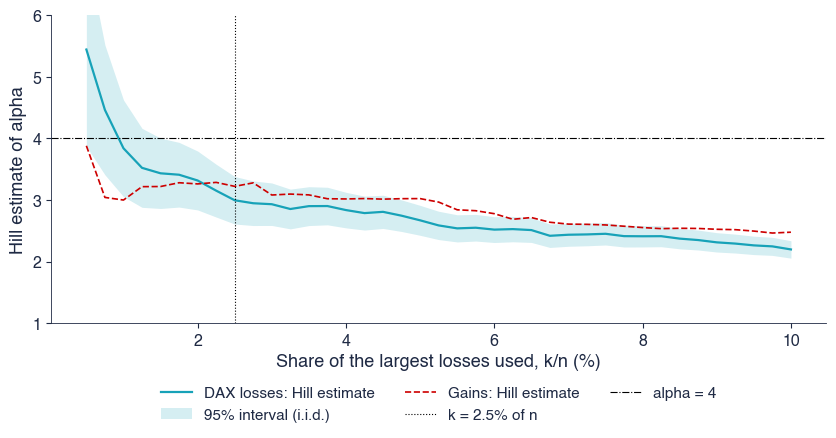

In [14]:
# Solution
def b1_hill(name='dax', save=True, plot=True):
    """Hill plot and Hill inference (k = 2.5% of n, i.i.d. and moving-block bootstrap SE) for daily losses."""
    L = losses(name)
    x = L.values
    n = len(x)
    h = hill_inference(x)
    h['alpha_gain'] = hill(-x, h['k'])
    h['first'] = L.index[0].date().isoformat()
    h['last'] = L.index[-1].date().isoformat()
    h['kurt'] = float(stats.kurtosis(x))
    if plot:
        fr = np.round(np.arange(0.005, 0.1001, 0.0025), 4)
        kk = np.maximum((fr * n).astype(int), 5)
        a = np.array([hill(x, k) for k in kk])
        fig, ax = plt.subplots(figsize=(10, 4.0))
        ax.plot(100 * fr, a, color=COLORS[name], lw=1.6, label=f'{LABELS[name]} losses: Hill estimate')
        ax.fill_between(100 * fr, a * (1 - 1.96 / np.sqrt(kk)), a * (1 + 1.96 / np.sqrt(kk)), color=COLORS[name], alpha=0.18, lw=0,
                        label='95% interval (i.i.d.)')
        ax.plot(100 * fr, [hill(-x, k) for k in kk], color=MODEL_COL['Normal'], lw=1.2, ls='--', label='Gains: Hill estimate')
        ax.axvline(100 * HILL_FRAC, color='black', lw=0.8, ls=':', label='k = 2.5% of n')
        ax.axhline(4, color='black', lw=0.8, ls='-.', label='alpha = 4')
        ax.set_xlabel('Share of the largest losses used, k/n (%)')
        ax.set_ylabel('Hill estimate of alpha')
        ax.set_ylim(1, 6)
        st.legend_outside_bottom(ax, ncol=3, y=-0.16)
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch5_sem_b1')
    return h


pd.Series(b1_hill('dax', save=False))

**Interpretation of the result.** $\alpha = 4$ lies about five block-bootstrap standard errors above $\hat\alpha$: the kurtosis of DAX returns does not exist, so the sample kurtosis is not a stable number.

## B2 [Proposed]: BET, Bitcoin and two BVB stocks

**Question.** Which of the BET, Bitcoin, OMV Petrom and Banca Transilvania has the heaviest tail of losses? Model: B1.

1. Compute $\hat\alpha$ at $k = 2.5\%$ of $n$ for each series, with the 95% interval and the block-bootstrap SE.
2. Add the estimates at $k = 1\%$ and $5\%$ of $n$.
3. Test the difference between the BET and Bitcoin with $z = (\hat\alpha_1 - \hat\alpha_2)/\sqrt{SE_1^2 + SE_2^2}$.
4. Interpretation: is Bitcoin's tail heavier than the BET's once the scale of the losses is set aside?

**Report:** one table, one $z$ and two sentences.

In [ ]:
# Your code here


## B3 [Solved]: POT for the BET

**Question.** How large are VaR 1%, ES 2.5% and VaR 0.1% of daily BET losses by EVT, compared with historical simulation and the Normal distribution?

1. Draw the empirical mean excess function and mark $u$ (the 90% quantile of the losses).
2. Fit a GPD to the excesses over $u$ by maximum likelihood; report $\hat\xi$ with its SE and $\hat\beta$.
3. Draw the QQ plot of the excesses against the fitted GPD.
4. Compute VaR 1%, ES 2.5% and VaR 0.1% by EVT, by historical simulation and by the Normal distribution.
5. Interpretation: which method would you use for the capital of a bank holding the BET, and why?

**Report:** the two charts, a table of nine numbers and two sentences.

{'u': 1.375, 'n_u': 725, 'xi': np.float64(0.223), 'se_xi': np.float64(0.047), 'beta': np.float64(1.018)}


,var1,es25,var01
EVT,4.44,4.81,9.56
Historical,4.33,4.80,9.64
Normal,3.39,3.41,4.52


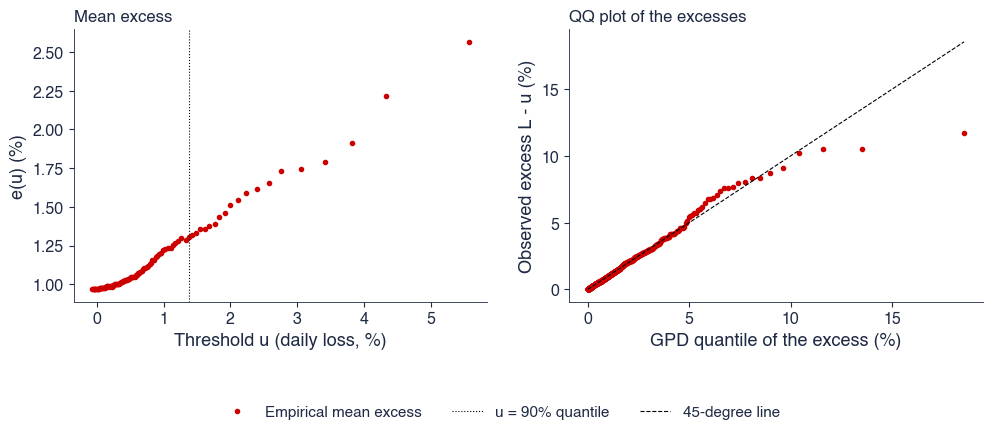

In [16]:
# Solution
def b3_pot(name='bet', save=True, plot=True):
    """POT with u = 90% quantile of the losses: GPD fit, mean excess, QQ plot; VaR 1%, ES 2.5% and VaR 0.1% by EVT,
    historical simulation and the Normal distribution."""
    L = losses(name)
    x = L.values
    f = pot(x)
    out = {'n': len(x), 'first': L.index[0].date().isoformat(), 'pot': f, 'e_u': float(mean_excess(x, [f['u']])[0])}
    for lab, p in [('var1', 0.01), ('var01', 0.001)]:
        out[lab] = {'EVT': pot_var(f, p), 'Historical': hist_var(x, p), 'Normal': normal_var(x, p)}
    out['es25'] = {'EVT': pot_es(f, 0.025), 'Historical': hist_es(x, 0.025), 'Normal': normal_es(x, 0.025)}
    if plot:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
        us = np.quantile(x, np.linspace(0.5, 0.995, 100))
        axes[0].plot(us, mean_excess(x, us), 'o', ms=3, color=COLORS[name], label='Empirical mean excess')
        axes[0].axvline(f['u'], color='black', lw=0.8, ls=':', label='u = 90% quantile')
        axes[0].set_xlabel('Threshold u (daily loss, %)')
        axes[0].set_ylabel('e(u) (%)')
        axes[0].set_title('Mean excess', loc='left', fontsize=12)
        y = np.sort(x[x > f['u']] - f['u'])
        pr = (np.arange(1, len(y) + 1) - 0.5) / len(y)
        q = stats.genpareto.ppf(pr, f['xi'], 0, f['beta'])
        axes[1].plot(q, y, 'o', ms=3, color=COLORS[name], label='_')
        lim = [0, max(q.max(), y.max())]
        axes[1].plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line')
        axes[1].set_xlabel('GPD quantile of the excess (%)')
        axes[1].set_ylabel('Observed excess L - u (%)')
        axes[1].set_title('QQ plot of the excesses', loc='left', fontsize=12)
        st.fig_legend_bottom(fig, ncol=3, y=0.0)
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch5_sem_b3')
    return out


b3 = b3_pot('bet', save=False)
print({c: round(b3['pot'][c], 3) for c in ['u', 'n_u', 'xi', 'se_xi', 'beta']})
pd.DataFrame({lab: b3[lab] for lab in ['var1', 'es25', 'var01']}).round(2)

**Interpretation of the result.** EVT agrees with the data at 1% and gives a smooth VaR 0.1%; the Normal VaR 0.1% is less than half of it.

## B4 [Proposed]: does the threshold matter? Bitcoin

**Question.** How much do $\hat\xi$ and the EVT risk measures of Bitcoin change with the threshold? Model: B3.

1. For $u$ at the 85%, 90% and 95% quantiles, fit the GPD and report $u$, $N_u$, $\hat\xi$ with its SE and $\hat\beta$.
2. Compute VaR 1%, ES 2.5% and VaR 0.1% for each threshold, and by historical simulation.
3. Interpretation: which quantity is robust to the choice of $u$, $\hat\xi$ or the VaR?

**Report:** one table and two sentences.

In [ ]:
# Your code here


## B5 [Solved]: quarterly maxima of the S&P 500

**Question.** How large is the daily loss that the S&P 500 exceeds once in 10 years, according to a GEV fit to quarterly maxima?

1. Build the quarterly maxima of the daily losses.
2. Fit a GEV by maximum likelihood; report $\hat\xi$ with its 95% interval, $\hat\mu$ and $\hat\sigma$.
3. Draw the QQ plot and the return level plot.
4. Compute the 10-year return level (40 quarters) and count the quarters above it.
5. Interpretation: is the S&P 500 tail Fréchet or Gumbel?

**Report:** three parameters, one level, the charts and one sentence.

xi            0.209
mu            1.969
sigma         0.860
se_xi         0.058
se_mu         0.079
se_sigma      0.062
nll         227.486
n           147.000
rl10          6.729
quarters    147.000
max          12.765
n_above       6.000
xi_lo         0.095
xi_hi         0.324
years        36.750
dtype: float64

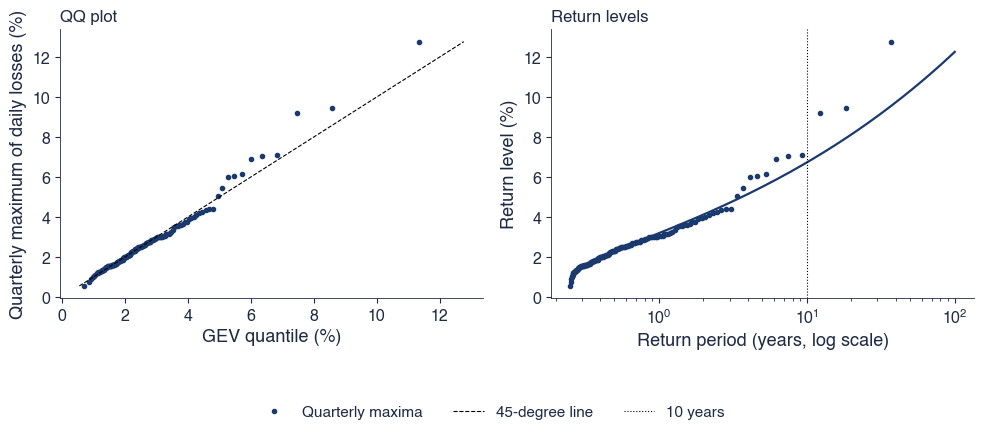

In [18]:
# Solution
def b5_quarterly(name='sp500', save=True, plot=True):
    """GEV fit to quarterly maxima of daily losses: xi (95% CI), 10-year return level (40 quarters), largest loss."""
    m = quarterly_maxima(name).values
    g = fit_gev(m)
    rl10 = float(gev_ppf(1 - 1 / 40, g['xi'], g['mu'], g['sigma']))
    out = dict(g, rl10=rl10, quarters=len(m), max=float(m.max()), n_above=int((m > rl10).sum()),
               xi_lo=g['xi'] - 1.96 * g['se_xi'], xi_hi=g['xi'] + 1.96 * g['se_xi'], years=len(m) / 4)
    if plot:
        ms = np.sort(m)
        p = (np.arange(1, len(ms) + 1) - 0.5) / len(ms)
        fig, axes = plt.subplots(1, 2, figsize=(10, 4.0))
        q = gev_ppf(p, g['xi'], g['mu'], g['sigma'])
        axes[0].plot(q, ms, 'o', ms=3, color=COLORS[name], label='Quarterly maxima')
        lim = [min(q.min(), ms.min()), max(q.max(), ms.max())]
        axes[0].plot(lim, lim, color='black', lw=0.8, ls='--', label='45-degree line')
        axes[0].set_xlabel('GEV quantile (%)')
        axes[0].set_ylabel('Quarterly maximum of daily losses (%)')
        axes[0].set_title('QQ plot', loc='left', fontsize=12)
        T = np.logspace(np.log10(0.3), np.log10(100), 200)
        axes[1].semilogx(T, gev_ppf(1 - 1 / (4 * T), g['xi'], g['mu'], g['sigma']), color=COLORS[name], lw=1.6, label='_')
        pe = np.arange(1, len(ms) + 1) / (len(ms) + 1)
        axes[1].semilogx(1 / (4 * (1 - pe)), ms, 'o', ms=3, color=COLORS[name], label='_')
        axes[1].axvline(10, color='black', lw=0.8, ls=':', label='10 years')
        axes[1].set_xlabel('Return period (years, log scale)')
        axes[1].set_ylabel('Return level (%)')
        axes[1].set_title('Return levels', loc='left', fontsize=12)
        st.fig_legend_bottom(fig, ncol=3, y=0.0)
        fig.tight_layout(rect=(0, 0.06, 1, 1))
        st.check_no_grey(fig)
        if save:
            st.save_fig('ch5_sem_b5')
    return out


pd.Series(b5_quarterly('sp500', save=False)).round(3)

**Interpretation of the result.** $\xi = 0$ lies outside the 95% interval: a Fréchet-type, heavy tail.

## B6 [Proposed]: does VaR 1% survive a new period?

**Question.** Estimated until 2014, is the VaR 1% of DAX and BET losses exceeded on about 1% of the days of 2015–2026? Models: B3, B5.

1. Estimate VaR 1% on the first period by EVT (POT, $u$ at the 90% quantile), historical simulation and the Normal distribution.
2. Count the test days with a loss above each VaR and compare with $np$.
3. Compute the two-sided binomial p-value of each count.
4. Interpretation: why can all three methods fail in the same direction?

**Report:** a table with six counts and p-values, and two sentences.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: has the tail of Bitcoin changed?

**Question.** Is the tail index of Bitcoin losses different in 2014–2017, 2018–2021 and 2022–2026? Models: B1, B2.

1. Compute the Hill $\hat\alpha$ at $k = 2.5\%$ of $n$ in each period, with the block-bootstrap SE and a 95% interval.
2. Say whether any two periods differ significantly.
3. Propose one change to the method that would give a sharper answer.
4. Interpretation: what can a sample of about 1,500 days say about a tail index?

**Report:** a table, one sentence per comparison and a plan for a project.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant estimated the tail of daily S&P 500 losses since 1990 by POT and claimed:

- (a) the GPD gives $\xi \approx 0.16$, so the tail index is $\alpha = 0.16$ and the variance is infinite;
- (b) VaR 1% $= u + (\beta/\xi)[(np/N_u)^{\xi} - 1]$;
- (c) ES 2.5% $=$ VaR 2.5% $\times (1 - \xi)$;
- (d) the same formula gives a reliable VaR 20%;
- (e) above $u$, the mean excess function of the fitted GPD is a straight line in the threshold.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** five verdicts with one line of justification each.

In [ ]:
# Your code here
